## Online Course Certificate Prediction

Given *data about online courses from MIT and Harvard*, let's try to predict whether a given course offers **honor code certificates**.

We will use a random forest classification model within a scikit-learn pipeline to make our predictions.

Data source: https://www.kaggle.com/datasets/edx/course-study

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = pd.read_csv('archive/appendix.csv')
data

,Institution,Course Number,Launch Date,Course Title,Instructors,Course Subject,Year,Honor Code Certificates,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),Certified,% Audited,% Certified,% Certified of > 50% Course Content Accessed,% Played Video,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher
0,MITx,6.002x,09/05/2012,Circuits and Electronics,Khurram Afridi,"Science, Technology, Engineering, and Mathematics",1,1,36105,5431,3003,15.04,8.32,54.98,83.2,8.17,28.97,418.94,64.45,26.0,88.28,11.72,60.68
1,MITx,6.00x,09/26/2012,Introduction to Computer Science and Programming,"Eric Grimson, John Guttag, Chris Terman",Computer Science,1,1,62709,8949,5783,14.27,9.22,64.05,89.14,14.38,39.50,884.04,78.53,28.0,83.50,16.50,63.04
2,MITx,3.091x,10/09/2012,Introduction to Solid State Chemistry,Michael Cima,"Science, Technology, Engineering, and Mathematics",1,1,16663,2855,2082,17.13,12.49,72.85,87.49,14.42,34.89,227.55,61.28,27.0,70.32,29.68,58.76
3,HarvardX,CS50x,10/15/2012,Introduction to Computer Science,"David Malan, Nate Hardison, Rob Bowden, Tommy ...",Computer Science,1,1,129400,12888,1439,9.96,1.11,11.11,0,0.00,1.11,220.90,0.00,28.0,80.02,19.98,58.78
4,HarvardX,PH207x,10/15/2012,Health in Numbers: Quantitative Methods in Cli...,"Earl Francis Cook, Marcello Pagano","Government, Health, and Social Science",1,1,52521,10729,5058,20.44,9.64,47.12,77.45,15.98,32.52,804.41,76.10,32.0,56.78,43.22,88.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,HarvardX,MUS24.4x,07/21/2016,First Nights: Symphonie Fantastique,Tom Kelly,"Humanities, History, Design, Religion, and Edu...",4,0,615,305,20,49.59,3.25,6.56,80.81,8.78,3.25,1.71,5.93,38.0,56.82,43.18,74.66
286,HarvardX,GSE4x,07/25/2016,Introduction to Family Engagement in Education,Karen Mapp,"Humanities, History, Design, Religion, and Edu...",4,0,2871,267,20,9.30,0.70,7.49,70.11,0.00,0.70,4.26,11.33,34.0,25.24,74.76,82.31
287,MITx,6.302.0x,08/01/2016,Introduction to Control System Design,"Jacob White, Joe Steinmeyer","Science, Technology, Engineering, and Mathematics",4,0,3937,974,49,24.74,1.24,5.03,12.27,4.72,8.23,15.62,58.50,24.0,91.17,8.83,61.32
288,MITx,6.302.1x,08/01/2016,Introduction to State Space Control,"Jacob White, Joe Steinmeyer","Science, Technology, Engineering, and Mathematics",4,0,1431,208,8,14.54,0.56,3.85,0,3.84,5.73,3.22,62.38,25.0,93.44,6.56,72.31


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Institution                                   290 non-null    str    
 1   Course Number                                 290 non-null    str    
 2   Launch Date                                   290 non-null    str    
 3   Course Title                                  290 non-null    str    
 4   Instructors                                   289 non-null    str    
 5   Course Subject                                290 non-null    str    
 6   Year                                          290 non-null    int64  
 7   Honor Code Certificates                       290 non-null    int64  
 8   Participants (Course Content Accessed)        290 non-null    int64  
 9   Audited (> 50% Course Content Accessed)       290 non-null    int64  
 10  C

### Preprocessing

In [4]:
df = data.copy()

In [5]:
# Drop unused columns
df = df.drop(['Course Number', 'Course Title', 'Instructors'], axis=1)

In [6]:
df

,Institution,Launch Date,Course Subject,Year,Honor Code Certificates,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),Certified,% Audited,% Certified,% Certified of > 50% Course Content Accessed,% Played Video,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher
0,MITx,09/05/2012,"Science, Technology, Engineering, and Mathematics",1,1,36105,5431,3003,15.04,8.32,54.98,83.2,8.17,28.97,418.94,64.45,26.0,88.28,11.72,60.68
1,MITx,09/26/2012,Computer Science,1,1,62709,8949,5783,14.27,9.22,64.05,89.14,14.38,39.50,884.04,78.53,28.0,83.50,16.50,63.04
2,MITx,10/09/2012,"Science, Technology, Engineering, and Mathematics",1,1,16663,2855,2082,17.13,12.49,72.85,87.49,14.42,34.89,227.55,61.28,27.0,70.32,29.68,58.76
3,HarvardX,10/15/2012,Computer Science,1,1,129400,12888,1439,9.96,1.11,11.11,0,0.00,1.11,220.90,0.00,28.0,80.02,19.98,58.78
4,HarvardX,10/15/2012,"Government, Health, and Social Science",1,1,52521,10729,5058,20.44,9.64,47.12,77.45,15.98,32.52,804.41,76.10,32.0,56.78,43.22,88.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,HarvardX,07/21/2016,"Humanities, History, Design, Religion, and Edu...",4,0,615,305,20,49.59,3.25,6.56,80.81,8.78,3.25,1.71,5.93,38.0,56.82,43.18,74.66
286,HarvardX,07/25/2016,"Humanities, History, Design, Religion, and Edu...",4,0,2871,267,20,9.30,0.70,7.49,70.11,0.00,0.70,4.26,11.33,34.0,25.24,74.76,82.31
287,MITx,08/01/2016,"Science, Technology, Engineering, and Mathematics",4,0,3937,974,49,24.74,1.24,5.03,12.27,4.72,8.23,15.62,58.50,24.0,91.17,8.83,61.32
288,MITx,08/01/2016,"Science, Technology, Engineering, and Mathematics",4,0,1431,208,8,14.54,0.56,3.85,0,3.84,5.73,3.22,62.38,25.0,93.44,6.56,72.31


In [11]:
# Fill missing values
df['% Played Video'] = df['% Played Video'].replace('---', np.nan).astype(float)
df['% Played Video'] = df['% Played Video'].fillna(df['% Played Video'].mean())

In [12]:
df.dtypes

Institution                                         str
Launch Date                                         str
Course Subject                                      str
Year                                              int64
Honor Code Certificates                           int64
Participants (Course Content Accessed)            int64
Audited (> 50% Course Content Accessed)           int64
Certified                                         int64
% Audited                                       float64
% Certified                                     float64
% Certified of > 50% Course Content Accessed    float64
% Played Video                                  float64
% Posted in Forum                               float64
% Grade Higher Than Zero                        float64
Total Course Hours (Thousands)                  float64
Median Hours for Certification                  float64
Median Age                                      float64
% Male                                          

In [13]:
# Extract date features
df['Launch Date'] = pd.to_datetime(df['Launch Date'])
df['Launch Year'] = df['Launch Date'].apply(lambda x: x.year)
df['Launch Month'] = df['Launch Date'].apply(lambda x: x.month)
df['Launch Day'] = df['Launch Date'].apply(lambda x: x.day)
df = df.drop('Launch Date', axis=1)

In [14]:
df

,Institution,Course Subject,Year,Honor Code Certificates,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),Certified,% Audited,% Certified,% Certified of > 50% Course Content Accessed,% Played Video,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher,Launch Year,Launch Month,Launch Day
0,MITx,"Science, Technology, Engineering, and Mathematics",1,1,36105,5431,3003,15.04,8.32,54.98,83.20,8.17,28.97,418.94,64.45,26.0,88.28,11.72,60.68,2012,9,5
1,MITx,Computer Science,1,1,62709,8949,5783,14.27,9.22,64.05,89.14,14.38,39.50,884.04,78.53,28.0,83.50,16.50,63.04,2012,9,26
2,MITx,"Science, Technology, Engineering, and Mathematics",1,1,16663,2855,2082,17.13,12.49,72.85,87.49,14.42,34.89,227.55,61.28,27.0,70.32,29.68,58.76,2012,10,9
3,HarvardX,Computer Science,1,1,129400,12888,1439,9.96,1.11,11.11,0.00,0.00,1.11,220.90,0.00,28.0,80.02,19.98,58.78,2012,10,15
4,HarvardX,"Government, Health, and Social Science",1,1,52521,10729,5058,20.44,9.64,47.12,77.45,15.98,32.52,804.41,76.10,32.0,56.78,43.22,88.33,2012,10,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,HarvardX,"Humanities, History, Design, Religion, and Edu...",4,0,615,305,20,49.59,3.25,6.56,80.81,8.78,3.25,1.71,5.93,38.0,56.82,43.18,74.66,2016,7,21
286,HarvardX,"Humanities, History, Design, Religion, and Edu...",4,0,2871,267,20,9.30,0.70,7.49,70.11,0.00,0.70,4.26,11.33,34.0,25.24,74.76,82.31,2016,7,25
287,MITx,"Science, Technology, Engineering, and Mathematics",4,0,3937,974,49,24.74,1.24,5.03,12.27,4.72,8.23,15.62,58.50,24.0,91.17,8.83,61.32,2016,8,1
288,MITx,"Science, Technology, Engineering, and Mathematics",4,0,1431,208,8,14.54,0.56,3.85,0.00,3.84,5.73,3.22,62.38,25.0,93.44,6.56,72.31,2016,8,1


In [16]:
df['Course Subject'].unique()

<StringArray>
[   'Science, Technology, Engineering, and Mathematics',
                                     'Computer Science',
               'Government, Health, and Social Science',
 'Humanities, History, Design, Religion, and Education']
Length: 4, dtype: str

In [17]:
# Split df into X and y
y = df['Honor Code Certificates'].copy()
X = df.drop('Honor Code Certificates', axis=1).copy()

In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

In [19]:
X_train

,Institution,Course Subject,Year,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),Certified,% Audited,% Certified,% Certified of > 50% Course Content Accessed,% Played Video,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher,Launch Year,Launch Month,Launch Day
107,MITx,"Government, Health, and Social Science",3,30780,7955,2689,25.84,8.74,32.13,75.53,15.29,13.53,110.41,12.23,29.0,78.22,21.78,72.88,2015,1,9
242,MITx,"Government, Health, and Social Science",4,4250,494,296,11.62,6.96,59.72,64.96,6.59,22.45,45.06,85.52,27.0,54.14,45.86,78.42,2016,2,22
245,HarvardX,"Humanities, History, Design, Religion, and Edu...",4,22153,4897,282,22.11,1.27,5.76,77.24,34.35,1.28,79.36,26.43,39.0,36.96,63.04,78.46,2016,3,1
79,HarvardX,"Government, Health, and Social Science",3,9010,2166,1494,24.07,16.60,68.98,58.71,22.92,39.80,40.60,15.92,31.0,49.87,50.13,82.70,2014,9,16
274,MITx,"Science, Technology, Engineering, and Mathematics",4,4825,715,92,14.82,1.91,12.87,67.83,5.37,33.49,29.82,49.80,26.0,54.56,45.44,68.23,2016,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,MITx,"Government, Health, and Social Science",4,2599,1172,436,45.09,16.78,37.20,69.41,16.93,42.17,30.39,33.65,28.0,59.53,40.47,76.87,2015,10,27
255,HarvardX,"Humanities, History, Design, Religion, and Edu...",4,3049,759,45,24.89,1.48,5.93,72.94,18.60,1.57,24.48,59.94,36.0,39.50,60.50,75.44,2016,4,8
72,MITx,"Science, Technology, Engineering, and Mathematics",3,11841,1532,502,12.94,4.24,32.77,62.87,4.90,13.95,81.04,63.12,25.0,84.01,15.99,65.85,2014,9,3
235,MITx,"Science, Technology, Engineering, and Mathematics",4,17354,1830,136,10.55,0.78,7.43,67.28,3.09,12.22,269.33,212.83,27.0,83.52,16.48,72.77,2016,2,2


In [21]:
y_train.value_counts()

Honor Code Certificates
1    166
0     37
Name: count, dtype: int64

### Building Pipeline

In [57]:
onehot_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, drop='if_binary'))
])

preprocessor = ColumnTransformer(transformers=[
    ('onehot', onehot_transformer, ['Institution', 'Course Subject'])
], remainder='passthrough')

model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            random_state=1,
            class_weight={
                0: 1.0,
                1: 0.5
            }
        ))
    ]
)

### Training

In [58]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Institution','Course Subject','Year',...,'Launch Year','Launch Month', 'Launch Day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

### Results

Accuracy: 97.70%


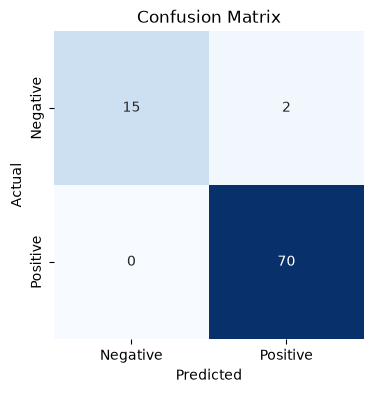

Classification Report:
-------------------------------
               precision    recall  f1-score   support

    Negative       1.00      0.88      0.94        17
    Positive       0.97      1.00      0.99        70

    accuracy                           0.98        87
   macro avg       0.99      0.94      0.96        87
weighted avg       0.98      0.98      0.98        87



In [59]:
y_pred = model.predict(X_test)
acc = model.score(X_test, y_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
clr = classification_report(y_test, y_pred, labels=[0, 1], target_names=['Negative', 'Positive'])

print("Accuracy: {:.2f}%".format(acc*100))

plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])
plt.yticks(ticks=[0.5, 1.5], labels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n-------------------------------\n", clr)